In [24]:
library(Seurat)
library(scop)
library(Signac)
library(ggplot2)
set.seed(4180)
library(patchwork)
setwd("/")
#########color
cols <- c("#444576", "#4682B4",
 "#AEDEEE","#FFA500",
 "#FFD790","#C65762","#FBDFDE",
 "#F6EFCF","#BCB99F")
pal <- colorRampPalette(cols)

In [2]:
vCM <- readRDS("data/vCM.Rds")
DefaultAssay(vCM) <- "RNA"

In [5]:
#S3a
suppressMessages(library(ROGUE))
suppressMessages(library(ggplot2))
suppressMessages(library(tidyverse))
rogue.res <- rogue(GetAssayData(vCM,assay = "RNA",layer = "counts"),
 labels = vCM$subtype,samples = vCM$id, platform = "UMI",
 span = 0.6)

In [17]:
p <- rogue.boxplot(rogue.res)

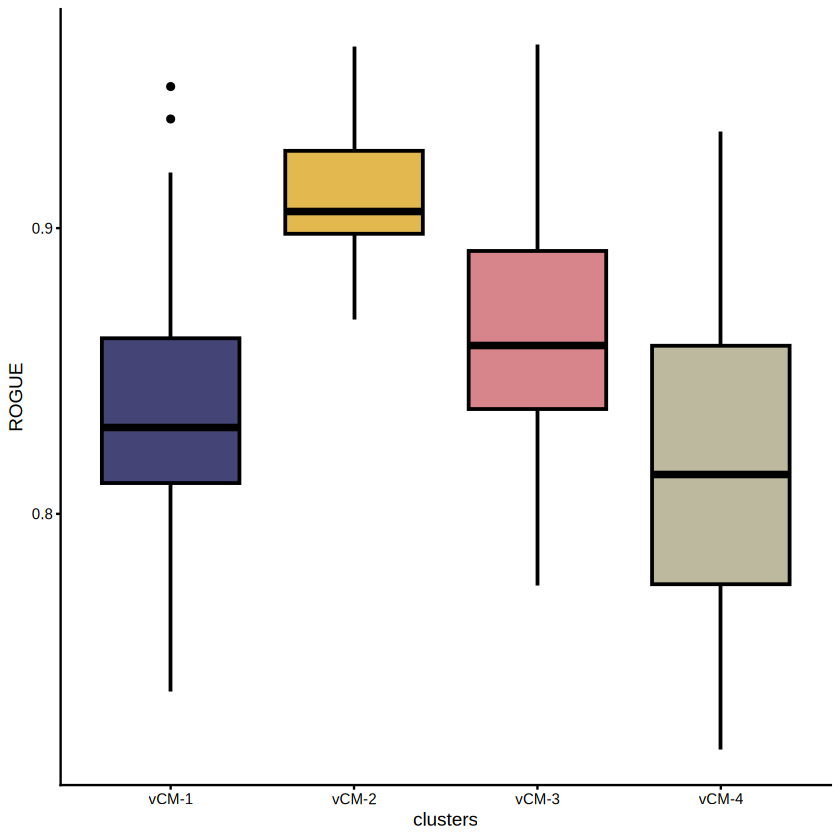

In [25]:
p1 <-ggplot(p$data, aes(x = clusters, y = ROGUE)) +
 geom_boxplot(aes(fill = clusters), color = "black", linewidth = 0.8) + 
 scale_fill_manual(values = pal(4)) + # custom fill colors
 theme_classic() + # built-in black axes and border
 theme(
 legend.position = "none",
 axis.text = element_text(color = "black"), # axis textcolors
 axis.ticks = element_line(color = "black") # axis tickcolors
 )
p1
ggsave("S3a.pdf",p1,path = "plot/figureS3/",width=3,height=3,create.dir = T)

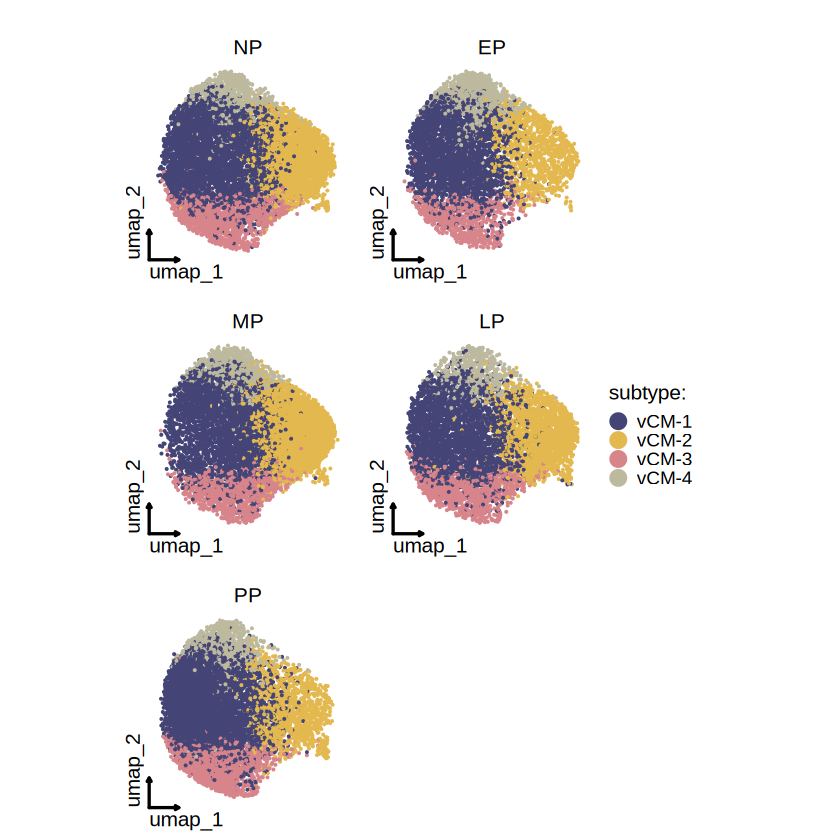

In [31]:
# fig2a
p <- CellDimPlot(
 srt = vCM, group.by = "subtype",
 legend.position = "right", label_repel = T,
 label_point_size = 0.1, reduction = "umap",
 label = F, label_insitu = T,
 theme_use = "theme_blank",
 palcolor = pal(4), raster = F,
 label.fg = "black", label.bg = "grey95",
 label.bg.r = 0, ncol=2, split.by="group"
)+ patchwork::plot_layout(
 guides = "collect"
)
ggsave(
 plot = p, filename = "S3b_vCMumap.pdf", path = "plot/figureS3/",
 create.dir = TRUE, width = 6, height = 8
)
p

In [95]:
#S3c
p1 <- FeatureDimPlot(vCM,features = c("Fabp3","Lgals4","Tcap",
 "Txnip","Pdk4","Cpt1b"),
 ncol=3,
 theme_use = "theme_blank")+ 
 patchwork::plot_layout(
 guides = "collect"
 )
ggsave(
 plot = p1, filename = "S3c.pdf", path = "plot/figureS3/",
 create.dir = TRUE, width = 8, height = 5
)

In [38]:
#S3d
DefaultAssay(vCM) <- "RNA"
vCM <- RunDEtest(vCM, group.by = "subtype", only.pos = FALSE, fc.threshold = 1)
vCM <- RunGSEA(vCM,
group.by = "subtype", DE_threshold = "p_val_adj < 0.05",
scoreType = "std", db = "GO_BP", species = "Mus_musculus"
)

ℹ [2026-05-09 09:25:09] Data type is log-normalized

ℹ [2026-05-09 09:25:09] Start differential expression test

ℹ [2026-05-09 09:25:10] Find all markers(wilcox) among [1] 4 groups...

ℹ [2026-05-09 09:25:10] Using 1 core

⠙ [2026-05-09 09:25:10] Running for vCM-1 [1/4] ■■          25% | ETA: 39s

⠹ [2026-05-09 09:25:10] Running for vCM-2 [2/4] ■■■■■       50% | ETA: 25s

⠸ [2026-05-09 09:25:10] Running for vCM-3 [3/4] ■■■■■■■     75% | ETA: 13s

✔ [2026-05-09 09:25:10] Completed 4 tasks in 51.2s



ℹ [2026-05-09 09:25:10] Building results

✔ [2026-05-09 09:26:01] Differential expression test completed

ℹ [2026-05-09 09:26:01] Start GSEA analysis

ℹ [2026-05-09 09:26:01] Species: "Mus_musculus"

ℹ [2026-05-09 09:26:01] Loading cached: GO_BP version: 3.22.0 nterm:15169 created: 2026-04-11 23:52:29

ℹ [2026-05-09 09:26:02] Using 1 core



⠙ [2026-05-09 09:26:02] Running for 1 [1/4] ■■          25% | ETA:  4m

⠹ [2026-05-09 09:26:02] Running for 2 [2/4] ■■■■■       50% | ETA:  3m

⠸ [2026

In [124]:
GSEA.data <- vCM@tools$GSEA_subtype_wilcox$enrichment
plot.path <- c("regulation of cytokine-mediated signaling pathway",
 "extracellular matrix organization",
 "cellular extravasation",
 "negative regulation of cell cycle G2/M phase transition",
 "cell-cell adhesion mediated by cadherin",
 "mitochondrial ATP synthesis coupled electron transport",
 "positive regulation of chromosome segregation",
 "regulation of oxidative phosphorylation",
 "ardiac muscle contraction",
 "actomyosin structure organization",
 "myofibril assembly")
plot.dt <- subset(GSEA.data,Description %in% plot.path)[,c(2,5,12)]
df_wide <- plot.dt %>%
 pivot_wider(
 id_cols = Description,
 names_from = Groups,
 values_from = NES,
 values_fill = 0,
 names_sort = TRUE
 )
df_wide <- data.frame(df_wide)
rownames(df_wide) <- df_wide$Description
colnames(df_wide) <- gsub("vCM.", "vCM-", colnames(df_wide))
library(ComplexHeatmap)
ht <- Heatmap(t(df_wide[, 2:5]),
 cluster_rows = F,
 col = c("#4682B4", "white", "#C65762"),
 column_dend_side = "bottom", show_row_dend = F,
 rect_gp = gpar(col = "grey30", lwd = 0.5),
 width = 4,
 height = 10,
 row_names_side = "left",
 column_names_side = "top",
 column_names_gp = gpar(fontsize = 10),
 column_names_rot = 45,
 heatmap_legend_param = list(title = "NES")
)
pdf(
 file = "plot/figureS3/S3d.pdf",
 width = 3.9,
 height = 4,
 useDingbats = FALSE,

)
draw(ht,padding = unit(c(3, 3, 3, 3), "mm"))
dev.off() # close device to generate the PDF

png 
  2